----------------------------------------------------
Machine Learning     

*Vanessa Gómez Verdejo vanessa@tsc.uc3m.es* and *Pablo M. Olmos olmos@tsc.uc3m.es*

----------------------------------------------------

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# use seaborn plotting defaults
%config InlineBackend.figure_format = 'retina'   ##QUALITY FIGURES!!
import seaborn as sns; sns.set()
plt.rcParams["figure.figsize"] = [6,6]

# 1. Introduction to kernel methods

## Review of linear models

Many of the algorithms presented in previous lessons are intended to infer a target variable $y$ (either a label or regressor) from a set of features $\mathbf{x}\in\mathbb{R}^D$, for this purpose, they define a linear model. For instance:
* **Linear regression** estimates the target variable for a new sample $\mathbf{x}^*$ as a linear combination of the input features:

$$\hat{y}^* = f(\mathbf{x}^*) = \mathbf{w}^T\mathbf{x}^*+w_0$$

* Both **logistic regression** and **support vector machines**, to separate the data of one class from the other, define a linear classification boundary given by
$$ f(\mathbf{x}) = \mathbf{w}^T\mathbf{x}+w_0=0$$



However, in many situations, the relationships between the observations and the target variables are rather nonlinear and we need models able to capture these relationships.

For instance, consider the following binary classification problem:





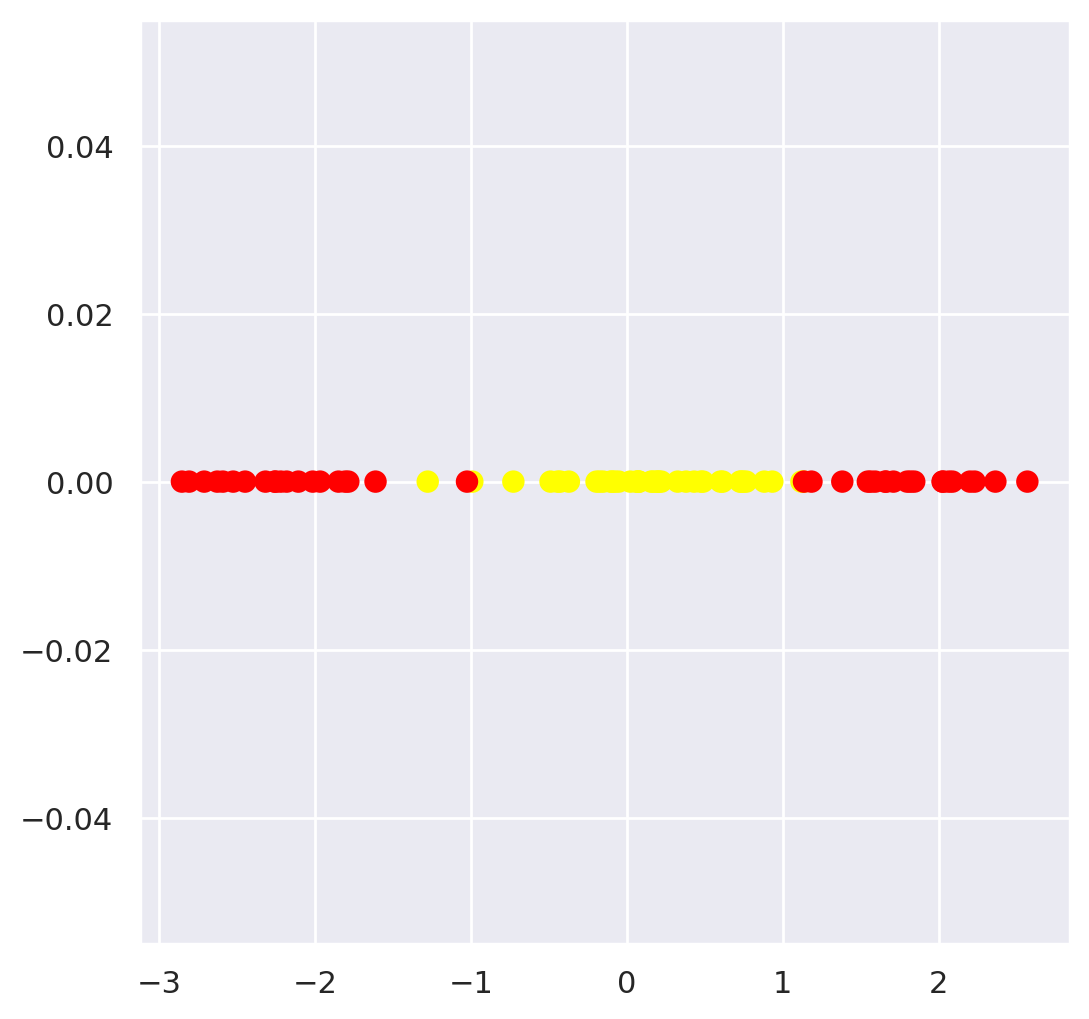

In [15]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Initialize the random generator seed to compare results
np.random.seed(0)

# Generating artifial data
X0 = 0.5*np.random.randn(40,1)
Y0 = np.ones((40,))
X1 = 0.5*np.random.randn(20,1)-2
X2 = 0.5*np.random.randn(20,1)+2
Y12 = -np.ones((40,))

X = np.concatenate((X0,X1,X2))
y = np.concatenate((Y0,Y12))

plt.figure()
plt.scatter(X, np.zeros((80,)), c=y, s=50, cmap='autumn')
plt.show()

Let's plot different possibles solutions of a linear classifier:

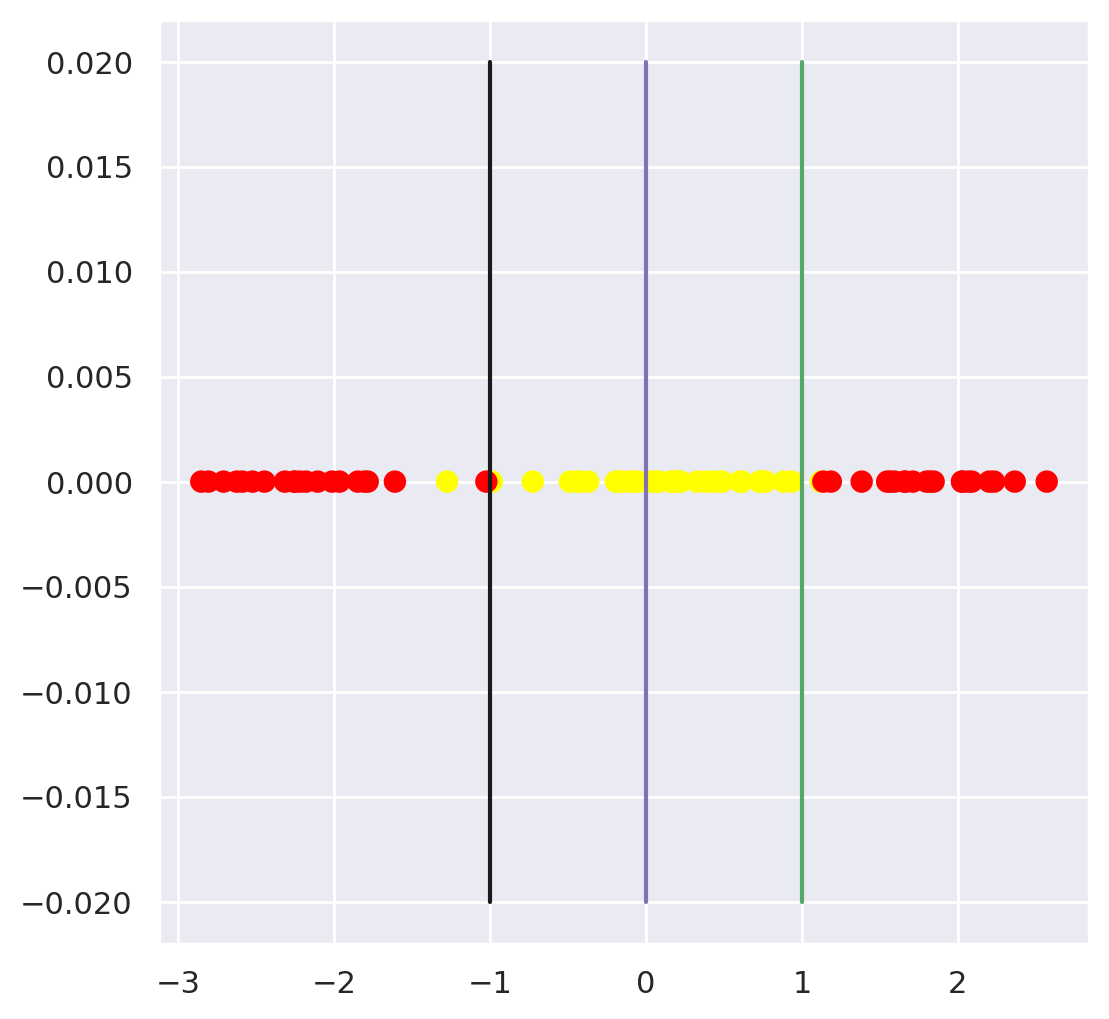

In [16]:
plt.figure()

xfit = np.linspace(-0.02, 0.02)

plt.scatter(X, np.zeros((80,)), c=y, s=50, cmap='autumn')


m,b = (0, -1)
plt.plot( m * xfit + b,  xfit,'-k')

m,b = (0, 0)
plt.plot( m * xfit + b,  xfit,'-m')

m,b = (0, 1)
plt.plot( m * xfit + b,  xfit,'-g')


we can check that any of these solutions is suboptimal. However, we know that we can find a no-linear solution with a polynomial extension of the input features.

## Polynomial extension

We have also seen that we can use a non-linear transformation of the input features to generate a new set of features. For example, if we consider the above classification problem (with a single input feature), we can create a new set of features with polynomial extension of degree $2$ as follows

$${\bf \phi}(\mathbf{x}) = [x, x^2]$$
where $\phi()$ is the transformation function.



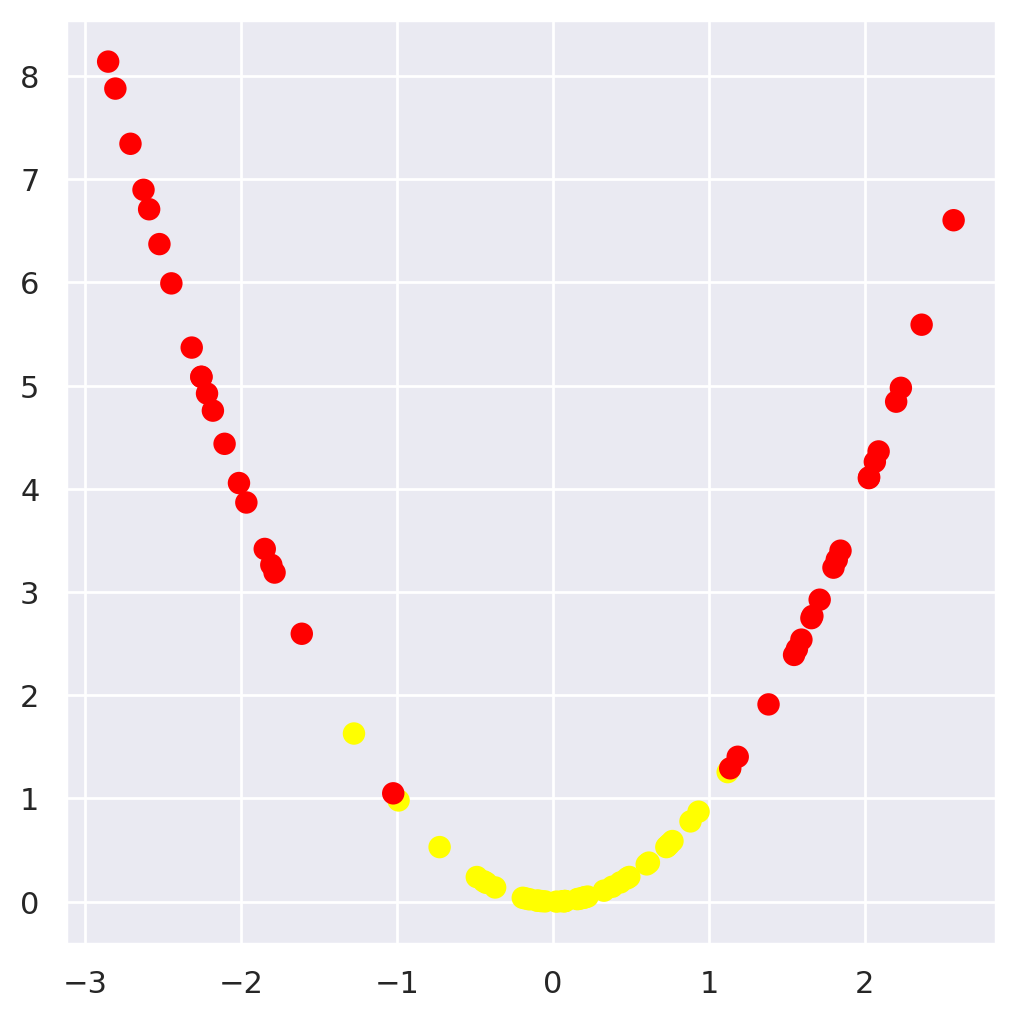

In [17]:
# Let's create the polynomial extension
phiX = np.hstack((X, X**2))

plt.figure()
plt.scatter(phiX[:, 0], phiX[:, 1],  c=np.squeeze(y), s=50, cmap='autumn')
plt.show()


Now, we can use these new features to learn our linear model:

$$f(x) = w_0 +w_1 \phi_1(\mathbf{x}) + w_2 \phi_2(\mathbf{x}) = w_0 +w_1 x + w_2 x^2 $$

For example, we can train a linear SVM with these new features.


In [18]:
from sklearn.svm import SVC # "Support vector classifier using the dual formulation"
model = SVC(kernel='linear', C=1)   # We use a linear kernel (no transformation), we will explain during next session.
                                       # Also, we explain below the role of C
model.fit(phiX, y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


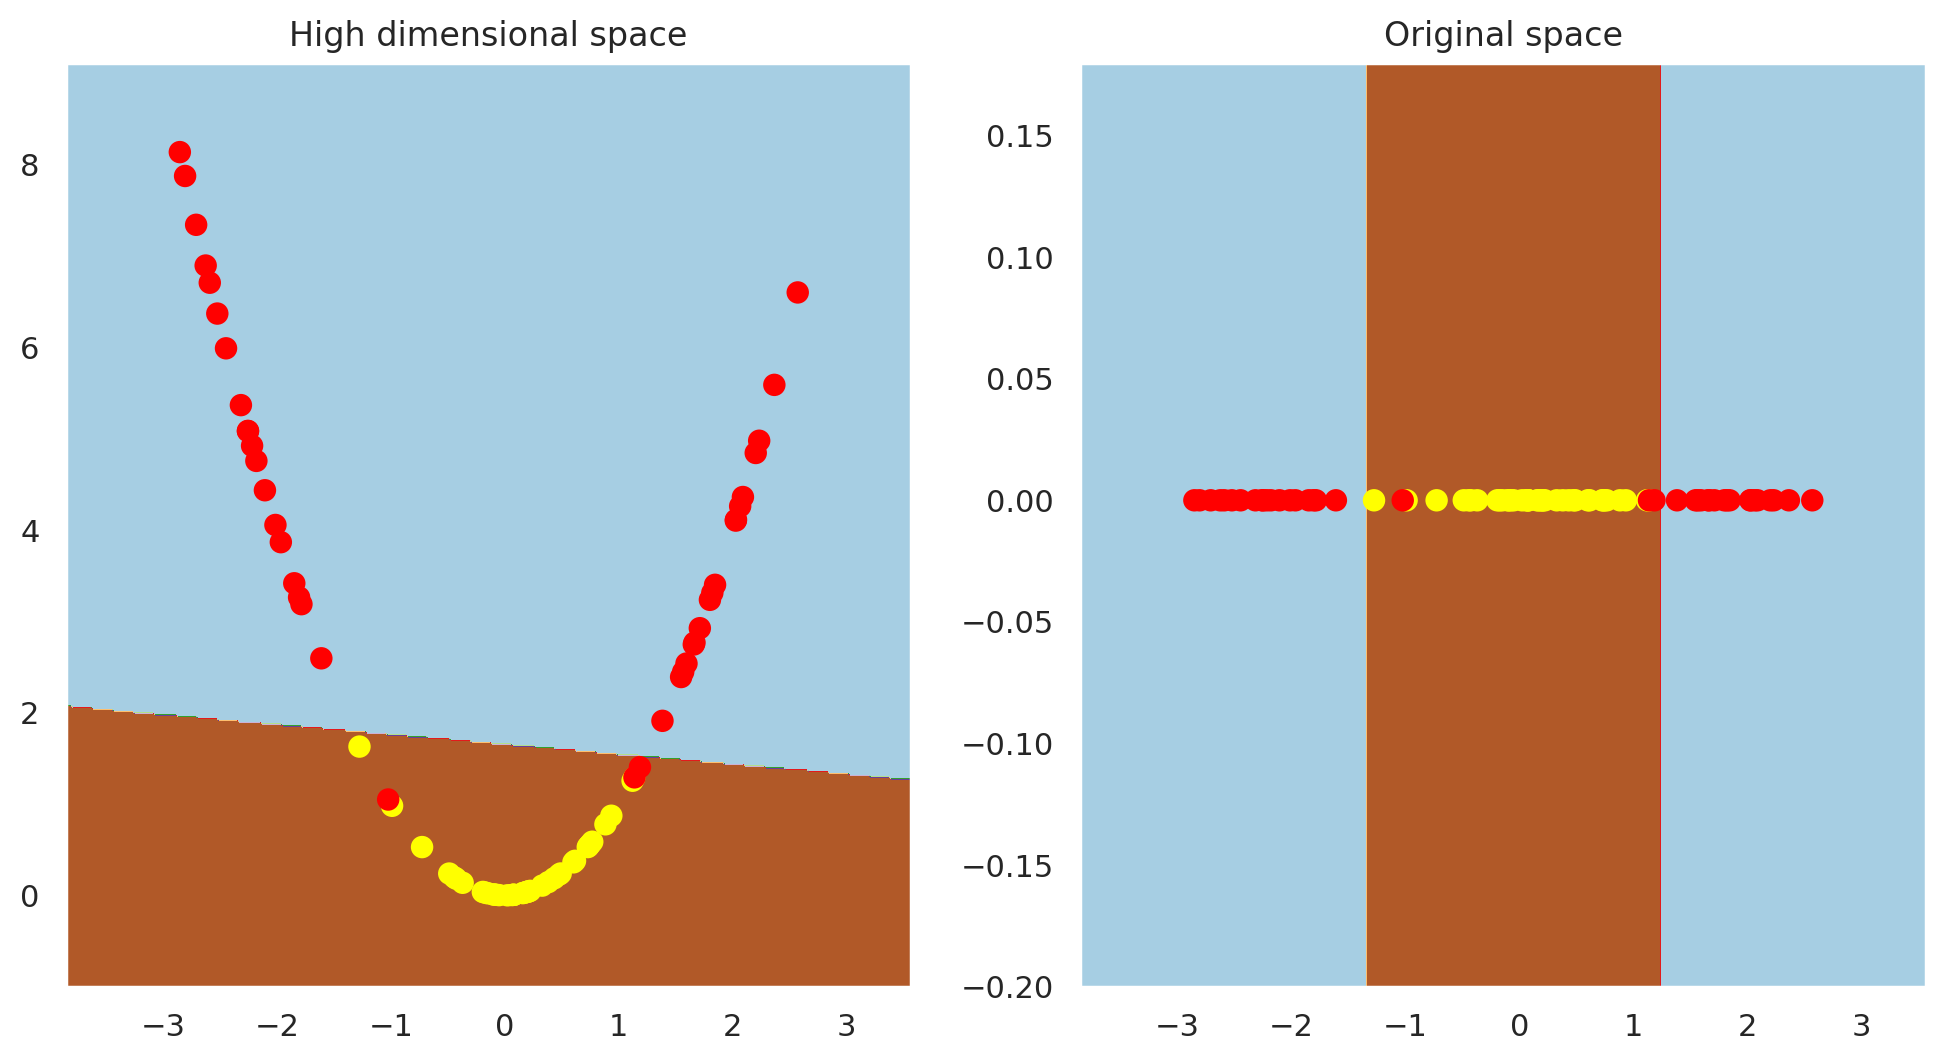

In [19]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plot_step = 0.02

x_min, x_max = phiX[:, 0].min() - 1, phiX[:, 0].max() + 1
y_min, y_max = phiX[:, 1].min() - 1, phiX[:, 1].max() + 1
XX, YY = np.meshgrid(np.arange(x_min, x_max, plot_step),
                        np.arange(y_min, y_max, plot_step))


xy = np.vstack([XX.ravel(), YY.ravel()]).T
P = model.predict(xy).reshape(XX.shape)

plt.contourf(XX, YY, P, cmap=plt.cm.Paired)

plt.scatter(phiX[:, 0], phiX[:, 1], c=y, s=50, cmap='autumn')

plt.title('High dimensional space')

plt.subplot(1,2,2)


x_min, x_max = X[:, 0].min() - 1, phiX[:, 0].max() + 1
y_min, y_max = -0.2, 0.2
XX, YY = np.meshgrid(np.arange(x_min, x_max, plot_step),
                        np.arange(y_min, y_max, plot_step))


xy = np.vstack([XX.ravel(), (XX**2).ravel()]).T
P = model.predict(xy).reshape(XX.shape)

plt.contourf(XX, YY, P, cmap=plt.cm.Paired)

plt.scatter(X, np.zeros((80,)), c=y, s=50, cmap='autumn')
plt.title('Original space')

plt.show()

Note that $\phi()$ representes the transformation function able to project the data from a space of dimension $D=1$ to a higher dimension space (in this case, $D'=2$). So, our model is linear in this high dimensional space, but the provided solution is nonlinear in the original space. That is, **a nonlinear model can be constructed by a nonlinear transformation to a space of higher dimension**.

But, can we generalize the transformation function $\phi()$ to any (no-)linear transformation of our observations? The answer to this question is **yes** and we can do it by means of the **kernel functions**.

## Kernel functions

Let's consider a mapping function ${\bf \phi}(\mathbf{x})$ able to find a new representation of our data from the input space to a high dimesional space, called **feature space**

\begin{align}
\phi(\mathbf{x}): \mathbb{R}^D \rightarrow \mathbb{R}^{D'},
\end{align}

where $D'\geq D$.

The kernel function, $K(\cdot,\cdot)$, is just the inner product of two data points in this new feature space:

 $$K(\mathbf{x},\mathbf{x}') = <\phi(\mathbf{x}),\phi(\mathbf{x}')> = \phi(\mathbf{x})^T\phi(\mathbf{x}')$$

We can see that the kernel is a symmetric function of its arguments since $K(\mathbf{x},\mathbf{x}') = K(\mathbf{x}',\mathbf{x})$.


The concept of a kernel formulated as an inner product in a feature space allows us to build interesting extensions of many well-known algorithms by making use of the  **kernel trick**, also known as kernel substitution.

The general idea is that, if we have an algorithm formulated in such a way that the input vector $\mathbf{x}$ enters only in the form of scalar products, then we can firstly map the data to the feature space and we can later replace that scalar product in the feature space with the associated kernel funtion.












# 2. Kernel formulation of SVMs

**Dual formulation of the SVMs**

As we know, the dual SVM formulation is given by the following optimization problem:

\begin{align}
&\max_{\mathbf{a}}  ~~~~ \sum_{i=1}^{N}a^{(i)} -\frac{1}{2}\sum_{i=1}^N \sum_{j=1}^N a^{(i)} a^{(j)} y^{(i)} y^{(j)}\color{red}{{\mathbf{x}^{(i)}}^\top\mathbf{x}^{(j)}}\\
\text{s.t.} ~~~~ & 0\leq a^{(i)} \leq C, ~ i=1,\ldots,N\\
& 0  = \sum_{i=1}^{N} a^{(i)}  y^{(i)}
\end{align}

that can be solved by QP solver to find the optimum value of the dual parameters $\mathbf{a}$ and, then, we can predict future values as:
\begin{align}
f(\mathbf{x}^*) &= \sum_{i=1}^{N} a^{(i)} y^{(i)} \color{red}{{\mathbf{x}^{(i)}}^\top\mathbf{x}^*}+w_0
\end{align}
note that $f(\mathbf{x}^*) = \mathbf{w}^T\mathbf{x}^*+w_0$ and $\mathbf{w} =\sum_{i=1}^N a^{(i)} y^{(i)} \mathbf{x}^{(i)}$.

Both the optimization problem to find dual parameters and the estimation function are expressed in terms of inner products of the input data, so we can apply the **kernel trick** to obtain a no-linear SVM formulation.

**Formulation of the SVMs in the feature space**

If we project our data into a feature space by means of a mapping function ${\bf \phi}(\cdot)$, we can rewrite the SVM formulation as:

\begin{align}
&\max_{\mathbf{a}}  ~~~~ \sum_{i=1}^{N}a^{(i)} -\frac{1}{2}\sum_{i=1}^N \sum_{j=1}^N a^{(i)} a^{(j)} y^{(i)} y^{(j)}\color{red}{{{\bf \phi}(\mathbf{x}^{(i)})}^\top {\bf \phi}(\mathbf{x}^{(j)})}\\
\text{s.t.} ~~~~ & 0\leq a^{(i)} \leq C, ~ i=1,\ldots,N\\
& 0  = \sum_{i=1}^{N} a^{(i)}  y^{(i)}
\end{align}

Now, applying the **kernel trick**, we can newly rewrite this formulation as:

\begin{align}
&\max_{\mathbf{a}}  ~~~~ \sum_{i=1}^{N}a^{(i)} -\frac{1}{2}\sum_{i=1}^N \sum_{j=1}^N a^{(i)} a^{(j)} y^{(i)} y^{(j)}\color{red}{K(\mathbf{x}^{(i)},\mathbf{x}^{(j)})}\\
\text{s.t.} ~~~~ & 0\leq a^{(i)} \leq C, ~ i=1,\ldots,N\\
& 0  = \sum_{i=1}^{N} a^{(i)}  y^{(i)}
\end{align}

Once dual parameters are obtained solving this new optimization problem, we can also apply the kernel trick over the prediction function to be able to classify new samples:
$$
f(\mathbf{x}^*) = \sum_{i=1}^{N} a^{(i)} y^{(i)} \color{red}{{{\bf \phi}(\mathbf{x}^{(i)})}^\top {\bf \phi}(\mathbf{x}^*)} +w_0 = \sum_{i=1}^{N} a^{(i)} y^{(i)} \color{red}{K(\mathbf{x}^{(i)},\mathbf{x}^*)}+w_0
$$


Note that this kernelized formulation has several advantages:

* A nonlinear SVM can be constructed by a nonlinear transformation to a higher dimension space (feature space). Then, we can find the maximum margin hyperplane that separates our training data in this feature space and, at the same time, finding a no-linear solution in the input space.

* The formulation is expressed in terms of the
kernel function. We don't even need to know the mapping function  ${\bf \phi}(\mathbf{x})$. It's enough to know all paired kernel values over the training data.

* If we wanted to recover the primal parameters ($\mathbf{w}$), the mapping function  ${\bf \phi}(\mathbf{x})$ should be known (which is not usually the case):
$$\mathbf{w} =\sum_{i=1}^N a^{(i)} y^{(i)} {\bf \phi}(\mathbf{x}^{(i)})$$
However, as we are using the formulation in terms of dual variables and kernel functions, this is not needed anymore.

* The output of the SVM can also be computed in terms of kernel functions. In this case we only have to compute the kernel between the new sample $\mathbf{x}^*$ and the training data. And, due to most $a^{(i)}$ values of the SVM solution are zero, it's enough to compute the kernel between the new sample $\mathbf{x}^*$ and the support vectors. Reducing the computational burden during the classification stage.

$$
f(\mathbf{x}^*) = \sum_{i \in SVs} a^{(i)} y^{(i)} K(\mathbf{x}^{(i)},\mathbf{x}^*)+w_0
$$

* The kernel can be understood as a similarity metric. So, vectors closest to $\mathbf{x}^*$ in the training set (in fact, only support vectors) are those that weight more in the prediction!




## Examples of kernel functions

In case we need to construct a kernel function, we could directly choose a feature space mapping $\phi(\mathbf{x})$. For instance, if $x\in\mathbb{R}$ we can choose the following transformation
\begin{align}
\phi(x) =[1, x, ~ x^2]
\end{align}

Then, the kernel function between two samples $x^{(1)}$ and $x^{(2)}$ is given by:
\begin{align}
k(x^{(1)},x^{(2)}) = \phi(x^{(1)})^{\top} \phi(x^{(2)})= 1+ (x^{(1)}x^{(2)}) + \left(x^{(1)}x^{(2)}\right)^2
\end{align}

However, the most common approach to construct kernel functions is to **directly choose the kernel**. In this case, we must ensure that the function we choose **corresponds to a scalar product in some (perhaps infinite dimensional) feature space** (technically, that [Mercer's theorem](http://people.cs.uchicago.edu/~niyogi/papersps/MinNiyYao06.pdf) has to be satisfied).

A very common kernel, that actually maps over an *infinite dimensional feature* space, is the **radial basis function (RBF) or Gaussian kernel**:

\begin{align}
k(\mathbf{x},\mathbf{x}') = \exp \left( -\frac{||\mathbf{x}-\mathbf{x}'||^2}{2\sigma^2} \right) = \exp \left( -\gamma ||\mathbf{x}-\mathbf{x}'||^2 \right)
\end{align}

where $\sigma$ is called the bandwidth and it is a hyperparameter that typically has to be adjusted by *cross validation*. Some implementations use an equivalent parameter $\gamma=\frac{1}{2\sigma^2}$.

Examples of other kernels are:
- Linear kernel:
$$k(\mathbf x_1, \mathbf x_2) = \mathbf x_1^\top \mathbf x_2$$
- Polynomial kernel:

$$k(\mathbf x_1, \mathbf x_2) = (\mathbf x_1^\top \mathbf x_2 + c)^d $$ 

with $d$ being the degree of the polynomial
- Exponentiation of a distance is a kernel
- Combinations of kernels are kernels


Check this [**link**](http://scikit-learn.org/stable/modules/metrics.html) to see possible examples of kernels that can be used within sklearn.

### Exercise 1

To analyze the advantages of this formultion, next cell generates a no-linear classification problem.

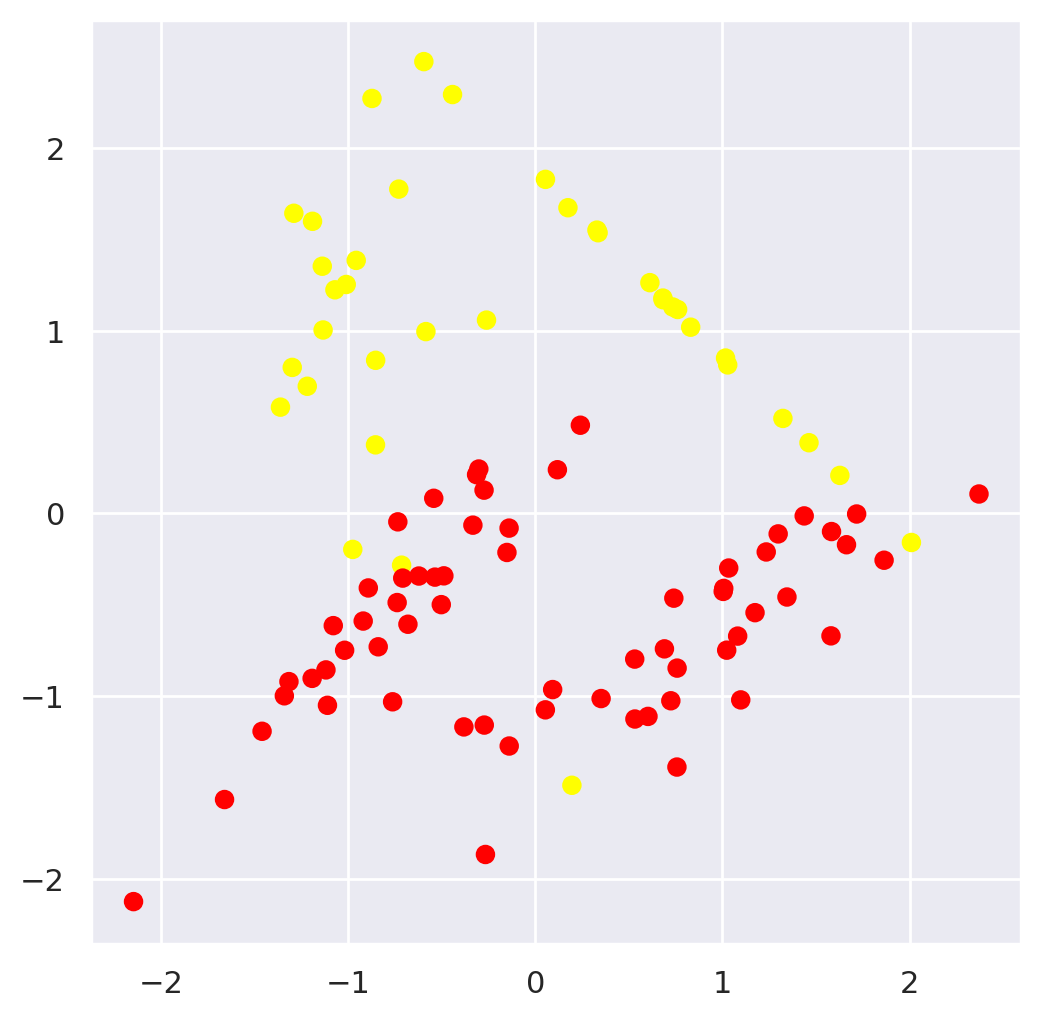

In [20]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Initialize the random generator seed to compare results
np.random.seed(0)

# Generating artifial data
X, Y = datasets.make_classification(n_samples=500, n_features=2, n_classes = 2, n_clusters_per_class=2,
                                    class_sep=1.5, n_redundant=0, flip_y =0.01)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.8)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap='autumn')
plt.show()

### Exercise 1.1 Linear SVM

Analyze the performance of a linear SVM over the above problem. For the sake of simplicity, you can use a default value of `C = 1`. Once the classifier is trained:
* Compute the accuracy over the test data
* Use the function `plot_svc_decision_function()` to plot the classification problem and the SVM solution (togheter to the support vectors).

In [25]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:            #If no figure handle is provided, it opens the current figure
        ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)    #30 points in the grid axis
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)                 # We create a grid with the x,y coordinates defined above

    # From the grid to a list of (x,y) values.
    # Check Numpy help for ravel()

    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    # In levels we provide a list of floating point numbers indicating
    #the level curves to draw, in increasing order; e.g., to draw just the zero contour pass
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, marker='+')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

#### Solution

Linear SVM Test Accuracy: 0.8875


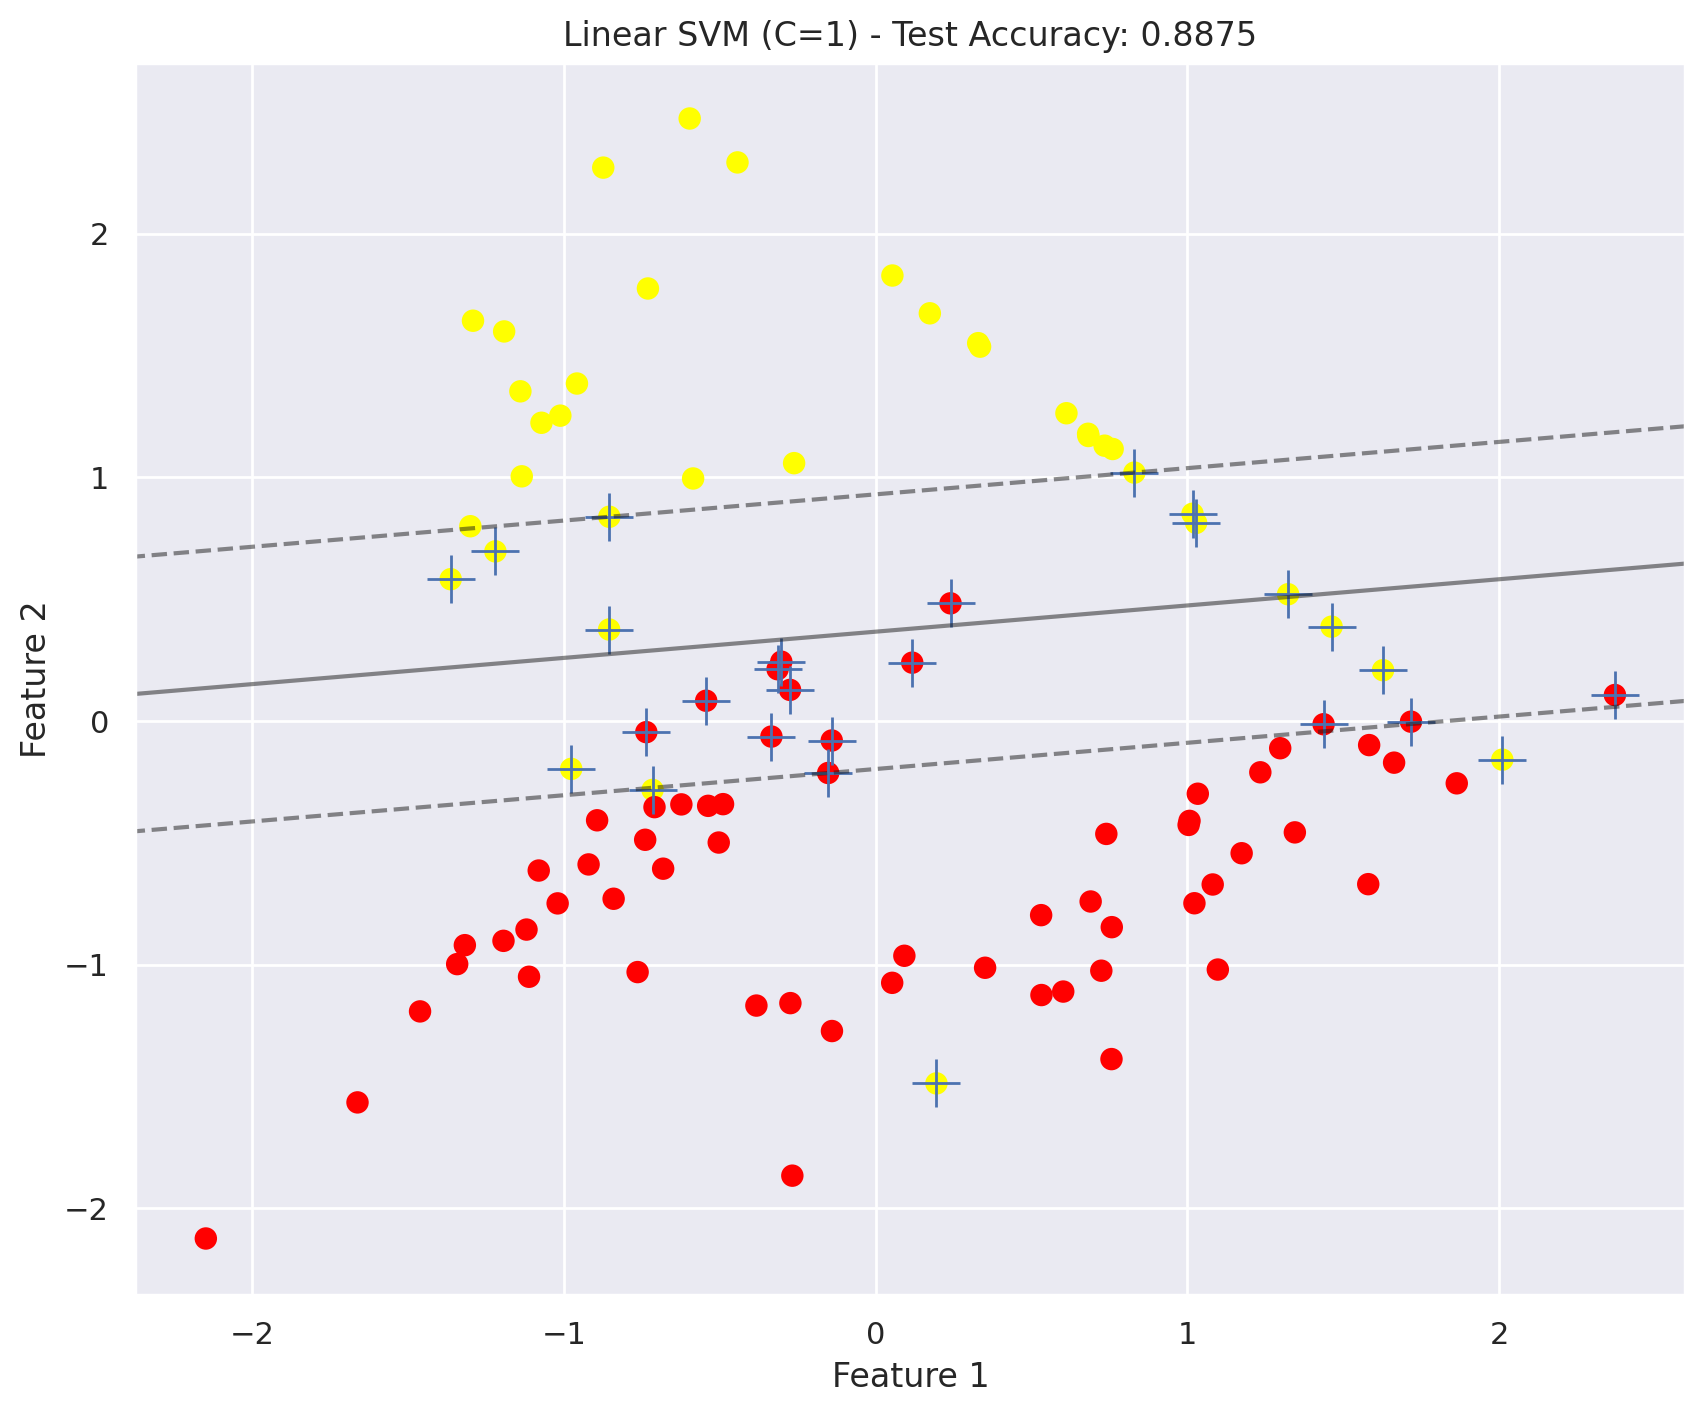

In [22]:
from sklearn.metrics import accuracy_score

# Train a linear SVM
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X_train, Y_train)

# Compute accuracy on test data
y_pred = linear_svm.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print(f"Linear SVM Test Accuracy: {accuracy:.4f}")

# Plot the classification problem and SVM solution
plt.figure(figsize=(10, 8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap='autumn', s=50)
plot_svc_decision_function(linear_svm, plot_support=True)
plt.title(f'Linear SVM (C=1) - Test Accuracy: {accuracy:.4f}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercise 1.2 RBF SVM

Train a no-linear SVM with a RBF kernel. Note that the [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) implementation let you define the kernel to be used together the kernel parameters. For simplicity, set `C=1` and explore different values of the `gamma` parameter `[0.01, 0.1, 1, 10, 100]`. Compute the test error and plot the classification boundary (and its margin) with `plot_svc_decision_function()` function.


#### Solution

RBF SVM (C=1, γ=0.01) Test Accuracy: 0.8300
RBF SVM (C=1, γ=0.1) Test Accuracy: 0.8850
RBF SVM (C=1, γ=1) Test Accuracy: 0.9075
RBF SVM (C=1, γ=10) Test Accuracy: 0.9000
RBF SVM (C=1, γ=100) Test Accuracy: 0.7275


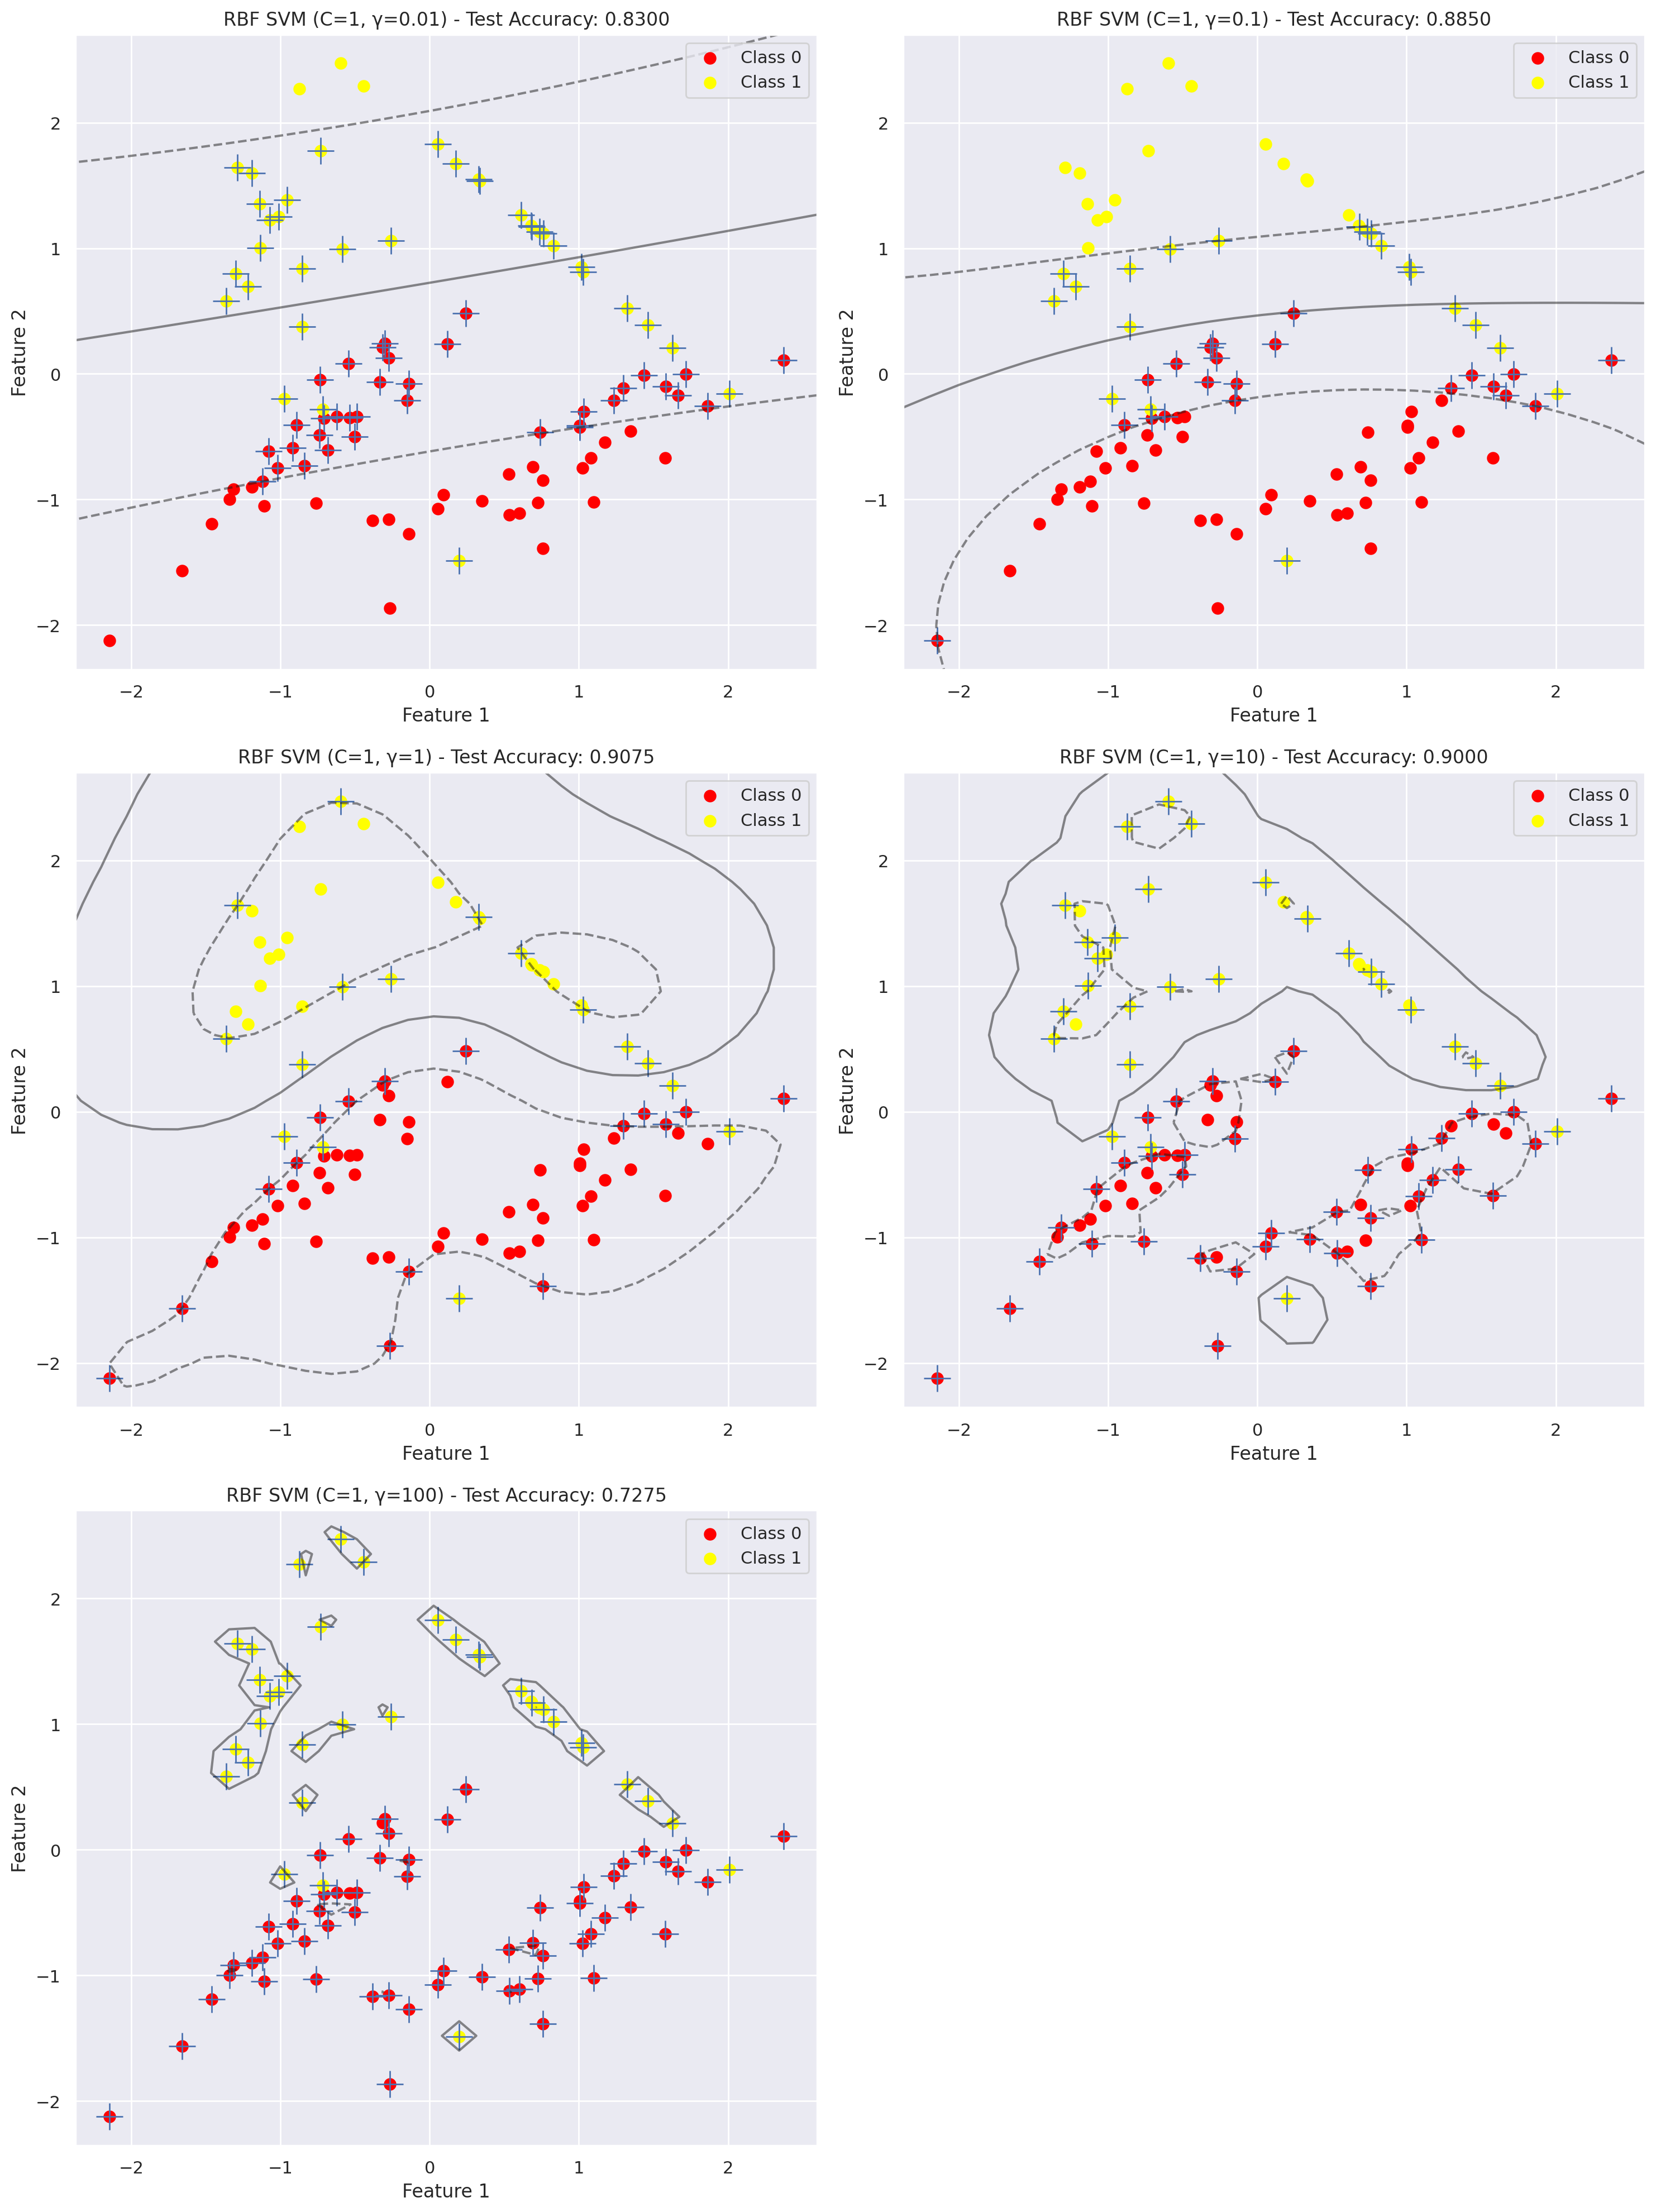

In [26]:
# Train RBF SVMs with different gamma values
gamma_values = [0.01, 0.1, 1, 10, 100]

plt.figure(figsize=(15, 20))

# Separate data for legend
X0 = X_train[Y_train == 0]
X1 = X_train[Y_train == 1]

for i, gamma in enumerate(gamma_values):
    # Train RBF SVM
    rbf_svm = SVC(kernel='rbf', C=1, gamma=gamma)
    rbf_svm.fit(X_train, Y_train)
    
    # Compute accuracy on test data
    y_pred = rbf_svm.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    
    # Plot the classification problem and SVM solution
    plt.subplot(3, 2, i+1)
    
    # Plot data points with labels for legend
    plt.scatter(X0[:, 0], X0[:, 1], c='red', s=50, label='Class 0')
    plt.scatter(X1[:, 0], X1[:, 1], c='yellow', s=50, label='Class 1')
    
    plot_svc_decision_function(rbf_svm, plot_support=True)
    plt.title(f'RBF SVM (C=1, γ={gamma}) - Test Accuracy: {accuracy:.4f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    
    print(f"RBF SVM (C=1, γ={gamma}) Test Accuracy: {accuracy:.4f}")

plt.tight_layout()
plt.show()

### Exercise 1.3 Analyze these results

In the light of the results try to answer the following questions:
* Why do small values of $\gamma$ (or large values of the RBF bandwidth) tend to provide linear solutions?.
* Why do large values of $\gamma$ (or small values of the RBF bandwidth) tend overfit?.


#### Answer

The `gamma` parameter in the RBF kernel SVM controls the influence of individual training samples on the decision boundary. It defines how far the influence of a single training example reaches, with low values meaning a far reach and high values meaning a close reach. This directly relates to the bias-variance tradeoff.

*   **Why do small values of γ tend to provide linear solutions?**

    A small `gamma` value means a large radius of influence for the support vectors. The RBF kernel function is $k(\mathbf{x},\mathbf{x}') = \exp(-\gamma ||\mathbf{x}-\mathbf{x}'||^2)$. When $\gamma$ is small, the kernel value decreases slowly as the distance between points increases. This means that points far away from a support vector can still have a significant influence on the decision boundary.

    As a result, the decision boundary becomes very smooth and less complex. In the limit, as $\gamma \to 0$, the decision boundary approaches a linear one. This is a **high-bias, low-variance** model, which is too simple to capture the non-linear structure in the data, leading to **underfitting**. Our plot for `γ=0.01` clearly shows this, with a nearly straight line that poorly separates the classes.

*   **Why do large values of γ tend to overfit?**

    A large `gamma` value means a very small radius of influence. The kernel value $\exp(-\gamma ||\mathbf{x}-\mathbf{x}'||^2)$ drops to zero very quickly as the distance between points grows. This means that only the points very close to a support vector have any influence on the decision boundary.

    The model becomes highly sensitive to individual data points, including noise and outliers. The decision boundary becomes very complex and "wiggly," creating tight, specific regions around each support vector to classify it correctly. This is a **low-bias, high-variance** model that has essentially "memorized" the training data.

    This phenomenon is called **overfitting**. The model performs exceptionally well on the training data but fails to generalize to new, unseen data. The plots for `γ=10` and `γ=100` show this clearly: the decision boundaries are extremely complex, and the test accuracy drops significantly for `γ=100`, indicating poor generalization.

------------------------

### Exercise 1.3 RBF SVM: parameter selection

Use a 5-fold CV process to adjust both $C$ and $\gamma$ parameters of a RBF SVM. Explore 10 values of $C$ from $0.001$ to $1000$, logarithmic equispaced, and define the range of $\gamma$ as: $[0.125, 0.25, 0.5, 1, 2, 4, 8])/D$,
being $D$ the data dimension. Note that this definition of the $\gamma$ values is used alleviate the influence of the data dimension in the definition of the RBF kernel.

Again, you can plot the final classification boundary and compute the test error to analyze the results.


#### Solution

Best parameters found:
C = 0.464159
γ = 2.000000
Best CV score: 0.9500
Test accuracy with best parameters: 0.9075


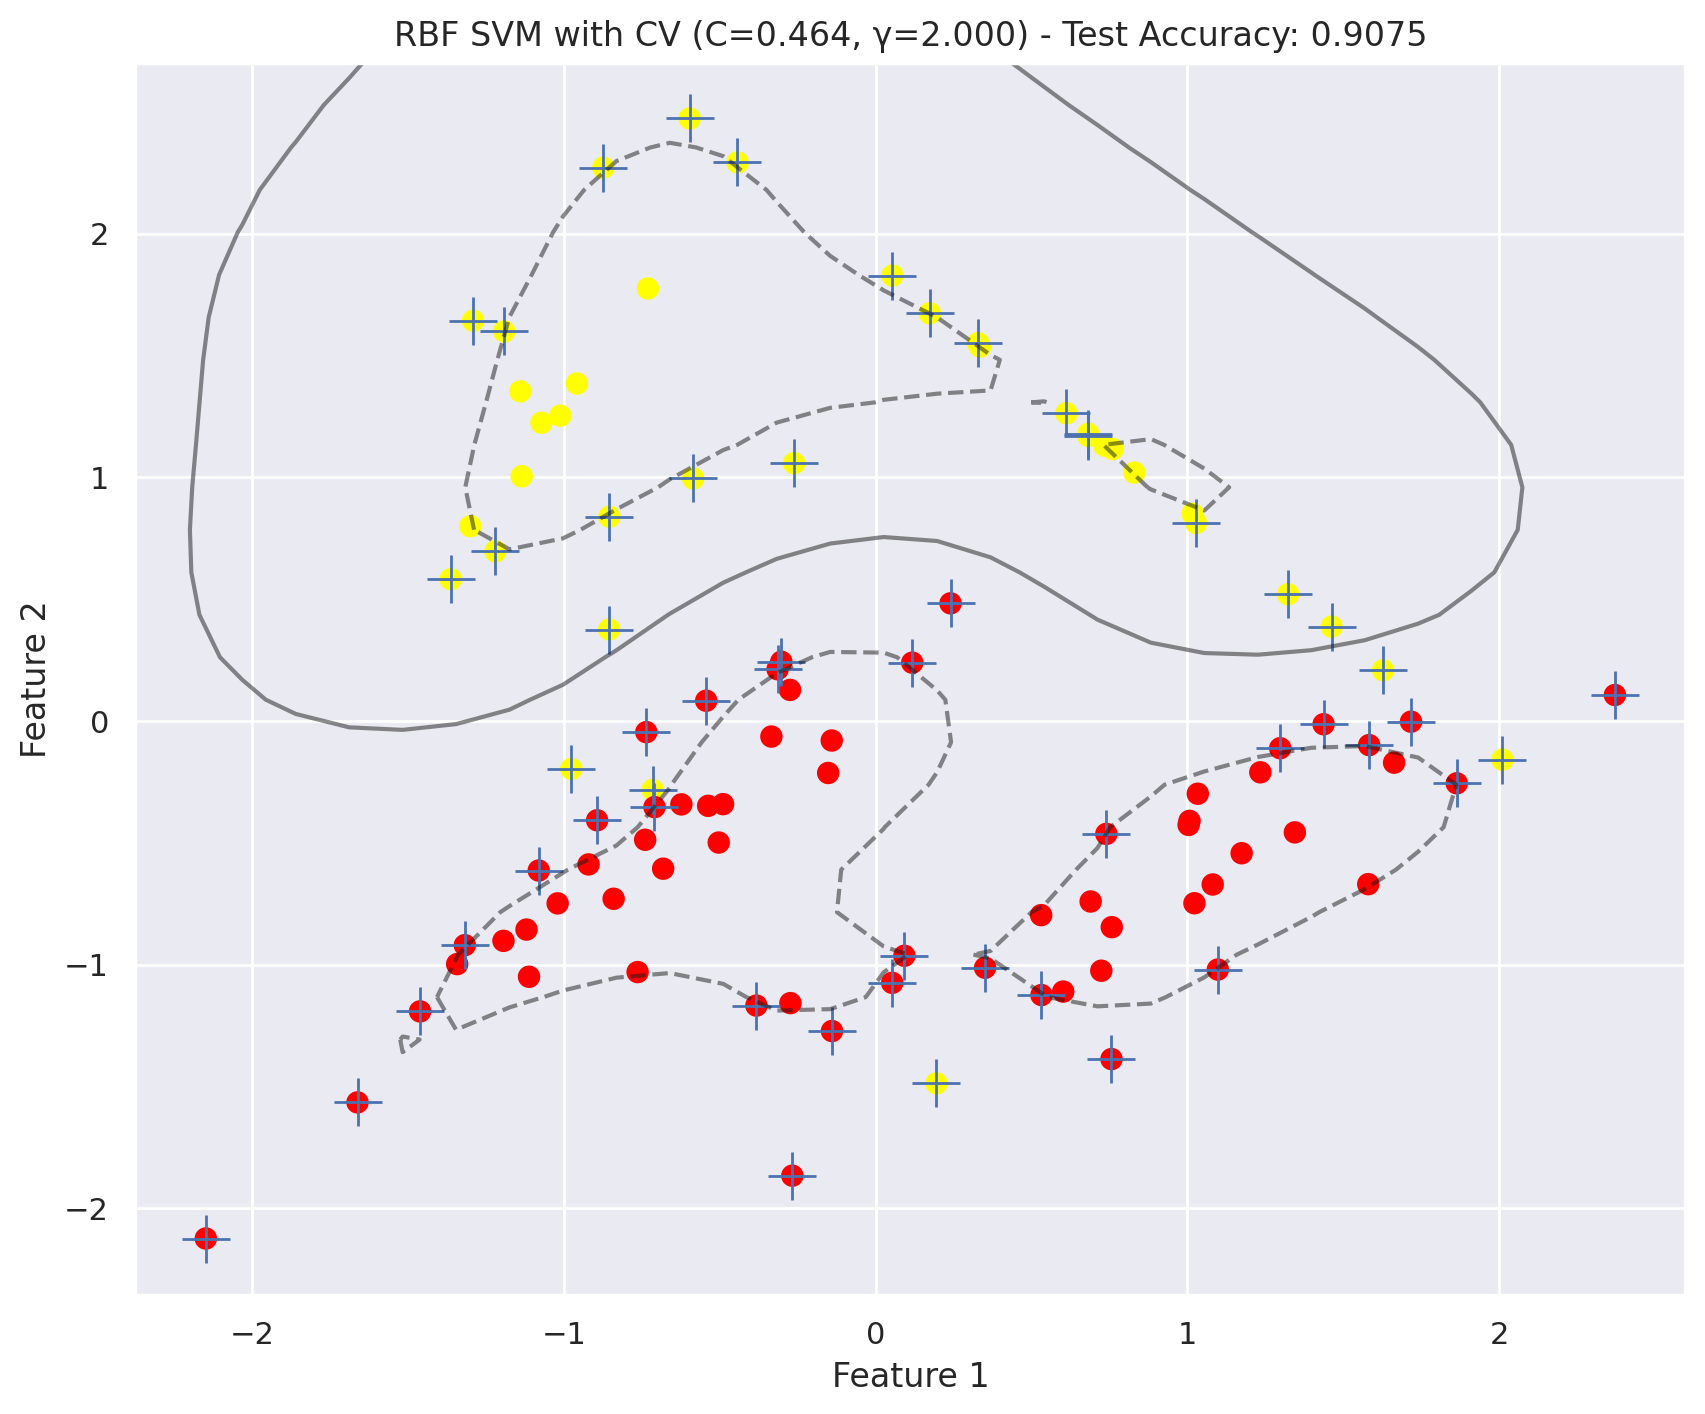

In [27]:
from sklearn.model_selection import GridSearchCV

# Get data dimension
D = X_train.shape[1]

# Define parameter ranges
C_values = np.logspace(-3, 3, 10)  # 10 values from 0.001 to 1000, logarithmic
gamma_values_scaled = np.array([0.125, 0.25, 0.5, 1, 2, 4, 8]) / D

# Create parameter grid
param_grid = {
    'C': C_values,
    'gamma': gamma_values_scaled
}

# Create RBF SVM
rbf_svm_cv = SVC(kernel='rbf')

# Perform 5-fold cross-validation
grid_search = GridSearchCV(rbf_svm_cv, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, Y_train)

# Get best parameters
best_C = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']

print(f"Best parameters found:")
print(f"C = {best_C:.6f}")
print(f"γ = {best_gamma:.6f}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_rbf_svm = grid_search.best_estimator_
y_pred_best = best_rbf_svm.predict(X_test)
best_accuracy = accuracy_score(Y_test, y_pred_best)

print(f"Test accuracy with best parameters: {best_accuracy:.4f}")

# Plot the final classification boundary
plt.figure(figsize=(10, 8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap='autumn', s=50)
plot_svc_decision_function(best_rbf_svm, plot_support=True)
plt.title(f'RBF SVM with CV (C={best_C:.3f}, γ={best_gamma:.3f}) - Test Accuracy: {best_accuracy:.4f}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Representer Theorem

**Can we extend the kernel formulation to other linear methods?**

The answer to this question is given by the [**Representer Theorem**](https://en.wikipedia.org/wiki/Representer_theorem) which, in simple terms, says that the solution of any algorithm obtained by the minimization of a regularized empirical cost can be represented as a weighted linear combination of the training data.

So, if we are working with a linear algorithm

$$
f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x}
$$

and we learn the weights $\mathbf{w}$ of this model by minimizing any regularized empirical cost function to find $\mathbf{w}^*$:

$$
\mathbf w^* =\displaystyle \underset{\bf{w}}{\operatorname{min}} \sum_{i=1}^N    L \left( f( {\mathbf x}^{(i)}) , y^{(i)} \right) + \lambda \Vert \mathbf{w} \Vert^2
$$

where $L \left( \cdot, \cdot \right)$ is the cost function (for instance, the binomial deviance in logistic regression or the MSE in linear regression); then, the Representer Theorem assures us that the parameters of the linear model are a linear combination of the training data
$$
\mathbf{w} =\sum_{i=1}^N a^{(i)} \mathbf{x}^{(i)}
$$
and, by substituting $\mathbf{w}$ into $f(\mathbf{x}^*)$:
$$
f(\mathbf{x}^*) = \sum_{i=1}^{N} a^{(i)} {\mathbf{x}^{(i)}}^\top\mathbf{x}^*
$$

Even, in case that we are working over the feature space generated by a mapping function $\phi(\mathbf{x})$, we can say that the algorithm output is given by a linear combination of kernel functions (inner products in this feature space)
$$
f(\mathbf{x}^*) = \sum_{i=1}^{N} a^{(i)}  K(\mathbf{x}^{(i)},\mathbf{x}^*)
$$
and now the goal of the model training (or inference) is learning these dual variables $a^{(1)}, \ldots, a^{(N)}$.

So, **if an algorithm fits the Representer Theorem, a dual expression
can be constructed as function of dot products (or kernel functions) between data**.

## Kernel Ridge Regression


### Ridge linear regression model in the feature space

Consider we have a **training** database of $N$ entries of the form $(\mathbf{x}^{(i)},y^{(i)})$, where $\mathbf{x}^{(i)}\in\mathbb{R}^D$ and $y^{(i)}\in\mathbb{R}$. Now, imagine that each of the input vectors is transformed into a **feature vector** as

\begin{align}
\phi(\mathbf{x}): \mathbb{R}^D \rightarrow \mathbb{R}^{D'},
\end{align}

where $D'\geq D$. We will use this training set to fit a model (in the feature space) of the form

$$f(\mathbf{x}) = \theta_0 + \theta_1 \phi(\mathbf{x})_1 + \theta_2 \phi(\mathbf{x})_2 + \ldots + \theta_{D'} \phi(\mathbf{x})_{D'} $$
note that the first element  of $\phi(\mathbf{x})$ is $1$, i.e. $\phi(\mathbf{x})_0=1$, so that it accomodates the intercept. And, the optimal values of $\boldsymbol{\theta}$ have to be found minimizing the **ridge loss function**:
$$ L(\boldsymbol{\theta},\lambda) = \frac{1}{N} \left[\sum_{i=1}^{N} (y^{(i)}-\boldsymbol{\theta}^T\phi(\mathbf{x}^{(i)}))^2 + \lambda \sum_{j=1}^{D'} \theta_j^2\right]
$$


### The dual problem representation

As this model satifies the Representer Theorem (it minimizes a regularized empirical cost), we know that the optimal solution ($\boldsymbol{\theta}^*)$ can be expressed as a **linear combination of the mapped training data**

\begin{align}
\boldsymbol{\theta}^* = \sum_{i=1}^{N} a^{(i)} \phi(\mathbf{x}^{(i)}) = \mathbf{\Phi}^T\mathbf{a},
\end{align}

Thus, given $\mathbf{a}$, the regression estimate for a new vector $\mathbf{x}^{*}$ is:

\begin{align}
f(\mathbf{x}^*) =  \sum_{i=1}^{N} a^{(i)} k(\mathbf{x}^{(i)},\mathbf{x}^*)
\end{align}


### Finding the vector of coefficients $\mathbf{a}$

If we substitute $\mathbf{\theta} = \mathbf{\Phi}^T\mathbf{a}$ in the Ridge Loss function we get the dual optimization problem. After some manipulation, the loss function is expressed in the following way:

\begin{align}
L(\mathbf{a},\lambda) = \frac{1}{N}\left[\mathbf{a}^T \mathbf{K}^T\mathbf{K}\mathbf{a}-2\mathbf{a}^T\mathbf{K}\mathbf{y}+\lambda\mathbf{a}^T\mathbf{K}\mathbf{a}\right],
\end{align}
where $\mathbf{K}$ is the $(N\times N)$ symmetric **kernel matrix** such that the element $(n,m)$ is
$$
k_{nm} = k(\mathbf{x}^{(m)},\mathbf{x}^{(n)}).
$$

$L(\mathbf{a},\lambda)$ is a convex function whose minimum is attained at
$$\mathbf{a} = \left(\mathbf{K}+\lambda \mathbf{I}\right)^{-1} \mathbf{y}.$$
Note that:
* The complexity (to obtain the dual variables) now increases as $\mathcal{O}(N^3)$ instead of the $\mathcal{O}(D^3)$ complexity that we had in the  primal space.
* The obtained solution is **not sparse** (in general, $\mathbf{a}$ values are not zero), unlike SVM solution; so, the estimation function
\begin{align}
f(\mathbf{x}^*) =  \sum_{i=1}^{N} a^i k(\mathbf{x}^{(i)},\mathbf{x}^*)
\end{align}
will need to compute all the kenels between all training data and the test sample to estimate its ouput.



### Exercise 2

Consider the following regression problem where a `sinc()` function has to be modeled.

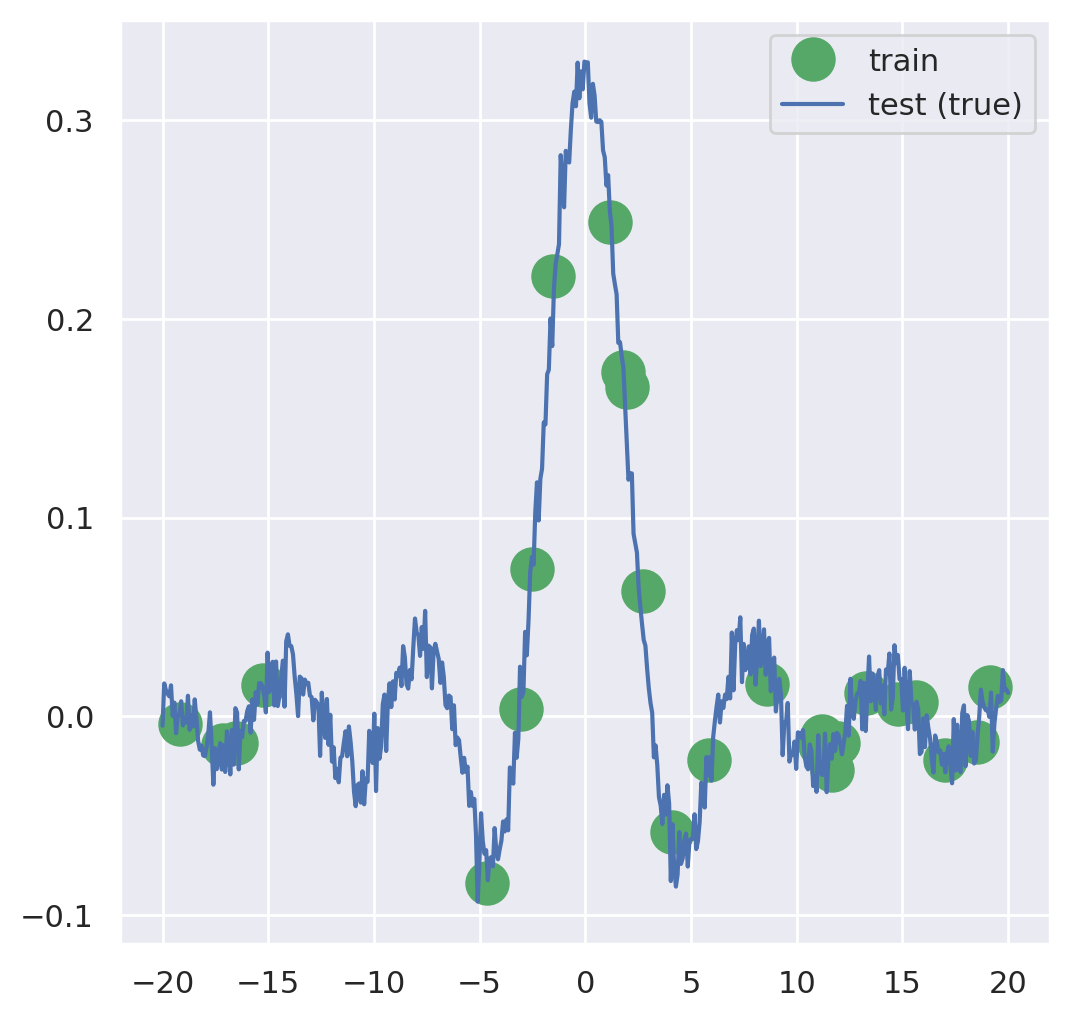

In [28]:
np.random.seed(0)

N_train = 25
R = 20
Xtrain = np.sort(np.random.uniform(-R,R,N_train), axis=0)       #Training points

Xtest = np.linspace(-R,R,500)      #Test points

def noise_sinc(X):
    Y = np.sin(X)/np.pi/(X+1e-6) + np.sqrt(1e-04) * np.random.randn(X.shape[0])
    return Y

Ytrain = noise_sinc(Xtrain)
Ytest = noise_sinc(Xtest)

Xtrain = Xtrain[:, np.newaxis] #Define 2-dimensional data (.fit does not work with 1-dimensional vectors)
Xtest = Xtest[:, np.newaxis]

plt.figure()
plt.plot(Xtrain,Ytrain,'go',ms=15,label='train')
plt.plot(Xtest,Ytest,'b-',label='test (true)')
plt.legend()
plt.show()

Now, train a kernel ridge linear regression (KRR) with a RBF kernel to estimate the `sinc()` function (you can start with its default parameters). Once the model has been trained:
* Analyze how does the kernel regressor behave as you vary either the number of training points, the alpha ($\lambda$) parameter, the bandwith in the RBF kernel ($\gamma$).
* How do you identify that the model is overfitting? or if the model is too biased? how do you regularize?
* Investigate also the effect of varying the kernel (linear, polynomial, ...)

You can use [**sklearn implementation of KRR**](http://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html#sklearn.kernel_ridge.KernelRidge)



#### Solution

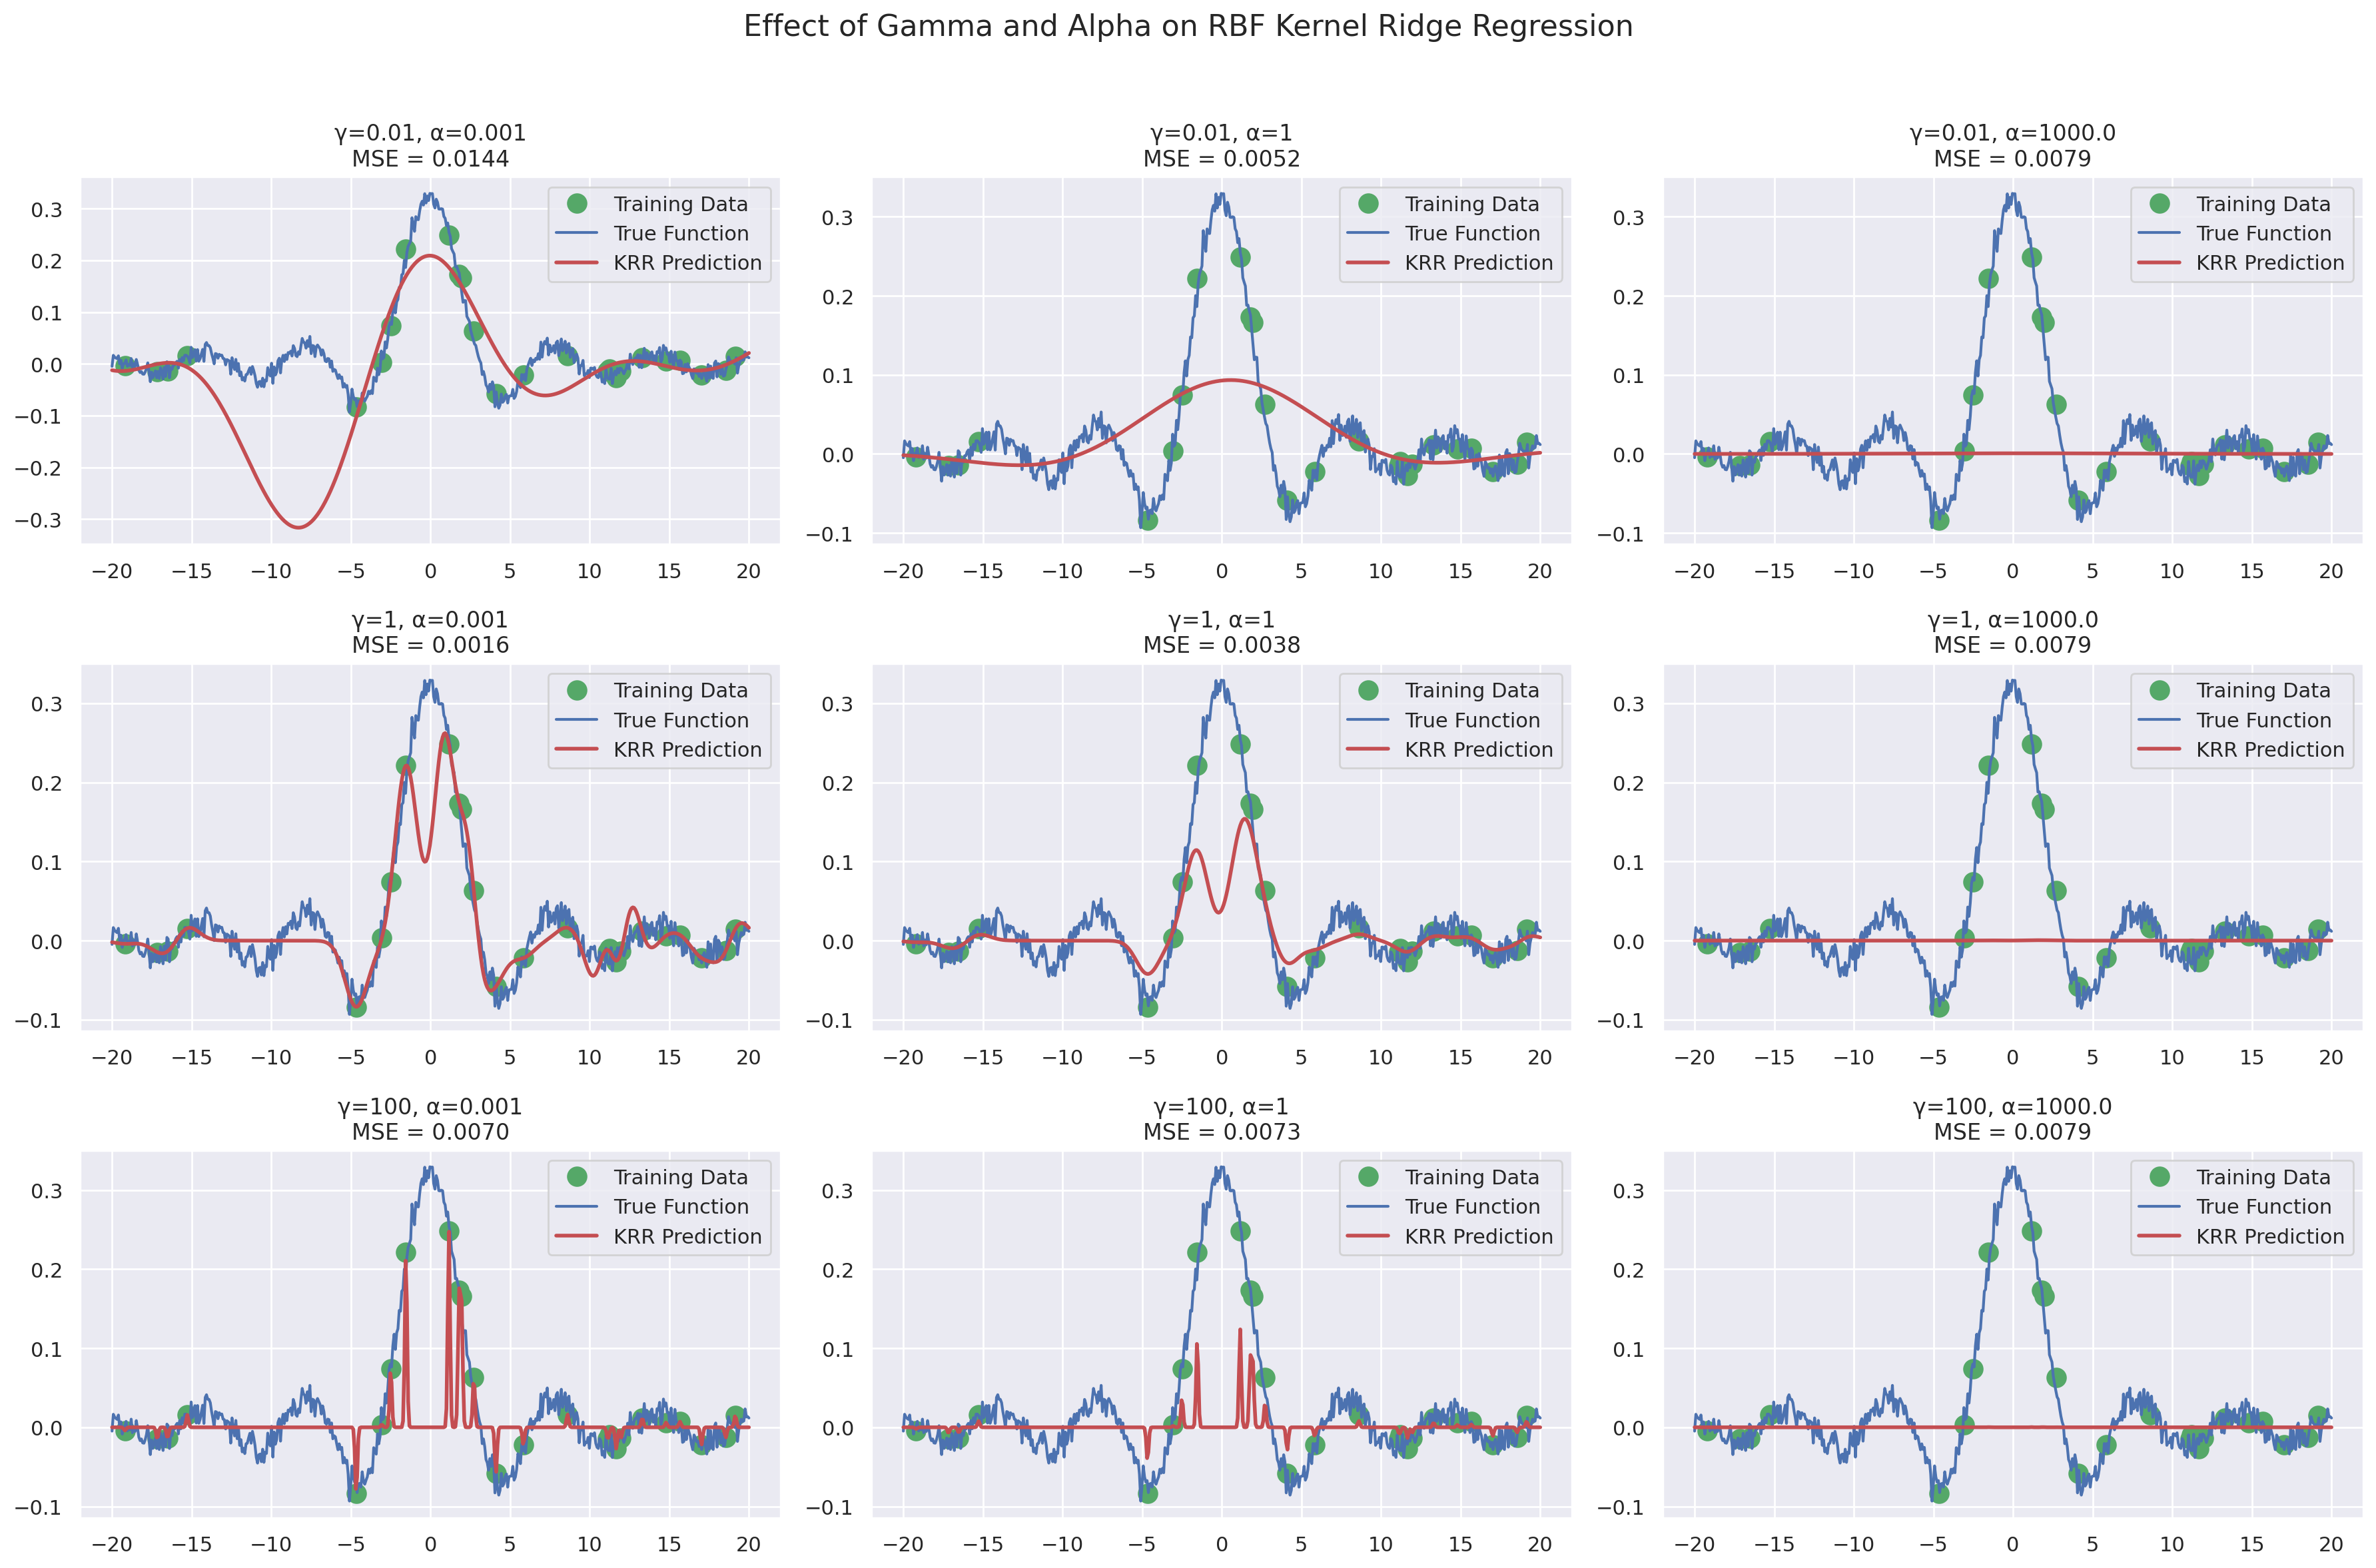

In [30]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error

# Let's analyze the effect of alpha (regularization) and gamma (RBF bandwidth)
alphas = [1e-3, 1, 1e3]
gammas = [0.01, 1, 100]

# Create a figure to plot the results
plt.figure(figsize=(18, 12))
i = 1

for gamma in gammas:
    for alpha in alphas:
        # Train the KRR model
        krr = KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma)
        krr.fit(Xtrain, Ytrain)
        
        # Make predictions on the test set
        Ypred = krr.predict(Xtest)
        
        # Calculate Mean Squared Error on test data
        mse = mean_squared_error(Ytest, Ypred)
        
        # Plot the results
        plt.subplot(len(gammas), len(alphas), i)
        plt.plot(Xtrain, Ytrain, 'go', ms=10, label='Training Data')
        plt.plot(Xtest, Ytest, 'b-', label='True Function')
        plt.plot(Xtest, Ypred, 'r-', lw=2, label='KRR Prediction')
        plt.title(f'γ={gamma}, α={alpha}\nMSE = {mse:.4f}')
        plt.legend()
        i += 1

plt.suptitle('Effect of Gamma and Alpha on RBF Kernel Ridge Regression', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

--- Analysis of the results ---

How to identify overfitting and bias:
1. Overfitting (High Variance): The model fits the training data almost perfectly but fails on test data.
   - In the plots: The red line is very "wiggly" and tries to pass through every green dot. This happens with a small alpha (low regularization) and a high gamma (localized influence).
   - See the plot for γ=100, α=0.001. The curve is extremely noisy, and the MSE would be high.

2. Underfitting (High Bias): The model is too simple and cannot capture the underlying trend of the data.
   - In the plots: The red line is too smooth and fails to follow the sinc() shape. This happens with a large alpha (strong regularization) or a very small gamma (overly broad influence).
   - See the plot for γ=0.01, α=1000. The model is almost a flat line.

How to regularize:
- To reduce overfitting (decrease variance): Increase `alpha`. A larger alpha forces the model weights (`a` coefficients) to be smaller, resulting in a smoother, less complex function.
- To reduce underfitting (decrease bias): Decrease `alpha` and/or adjust `gamma` to find a better fit for the data's complexity.

Effect of the number of training points:
- With fewer training points, the model is more likely to overfit because it has less information to learn the true underlying function.
- With more training points, the model gets a better approximation of the true function, and the risk of overfitting decreases.


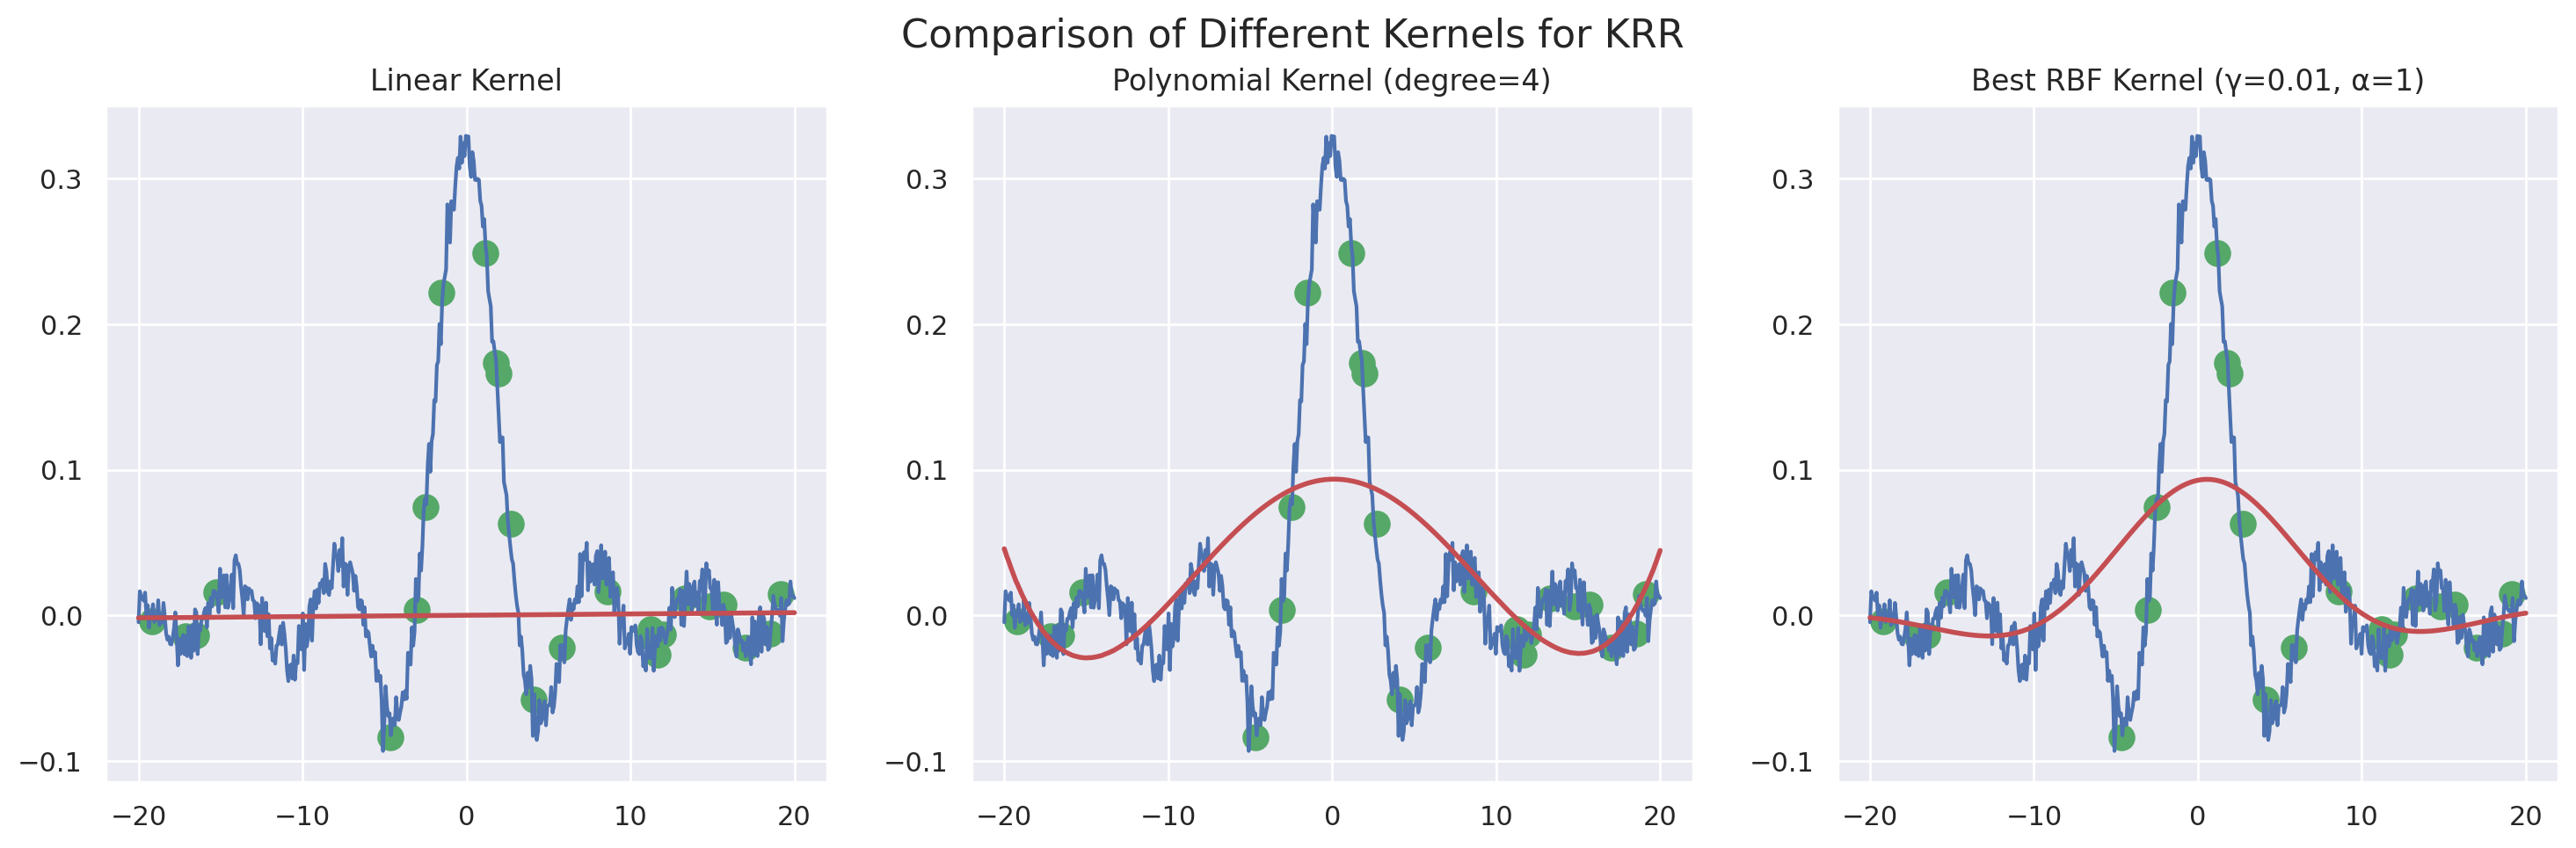

In [32]:
plt.figure(figsize=(18, 5))

# Linear Kernel
plt.subplot(1, 3, 1)
krr_linear = KernelRidge(kernel='linear', alpha=1)
krr_linear.fit(Xtrain, Ytrain)
Ypred_linear = krr_linear.predict(Xtest)
plt.plot(Xtrain, Ytrain, 'go', ms=10)
plt.plot(Xtest, Ytest, 'b-')
plt.plot(Xtest, Ypred_linear, 'r-', lw=2)
plt.title('Linear Kernel')

# Polynomial Kernel
plt.subplot(1, 3, 2)
krr_poly = KernelRidge(kernel='polynomial', alpha=1e-3, degree=4) # Polynomial kernel often needs tuning
krr_poly.fit(Xtrain, Ytrain)
Ypred_poly = krr_poly.predict(Xtest)
plt.plot(Xtrain, Ytrain, 'go', ms=10)
plt.plot(Xtest, Ytest, 'b-')
plt.plot(Xtest, Ypred_poly, 'r-', lw=2)
plt.title('Polynomial Kernel (degree=4)')

# Best RBF Kernel from above
plt.subplot(1, 3, 3)
krr_rbf_best = KernelRidge(kernel='rbf', alpha=1, gamma=0.01)
krr_rbf_best.fit(Xtrain, Ytrain)
Ypred_rbf_best = krr_rbf_best.predict(Xtest)
plt.plot(Xtrain, Ytrain, 'go', ms=10, label='Training Data')
plt.plot(Xtest, Ytest, 'b-', label='True Function')
plt.plot(Xtest, Ypred_rbf_best, 'r-', lw=2, label='KRR Prediction')
plt.title('Best RBF Kernel (γ=0.01, α=1)')

plt.suptitle('Comparison of Different Kernels for KRR', fontsize=16)
plt.show()

# Kernel comparison analysis:
# - Linear Kernel: As expected, it can only produce a straight line and is unable to model the non-linear sinc() function. It is severely underfitting.
# - Polynomial Kernel: It can capture some of the non-linear trends but might struggle to fit the complex oscillations of the sinc() function unless the degree is carefully chosen. It can also be unstable at the edges.
# - RBF Kernel: It is the most flexible and generally performs best for this kind of smooth, non-linear function, provided `alpha` and `gamma` are well-tuned.


## Kernel Logistic Regression (KLR)

We can also kernelize the formulation of the Logistic Regression classifier. As this algorithm is minimizing the regularized binomial deviance:

$$ L(\bf{w}) = \sum_{i=1}^N \left\lbrace   \log \left( 1+ \exp({\bf w}^T {\bf x}^{(i)})\right) \right\rbrace  -y^{(i)} ({\bf w}^T {\bf x}^{(i)}) + \lambda \Vert {\bf w} \Vert_2^2$$

it also satisfies the Representer Theorem, then we can claim that

$$\mathbf{w} =\sum_{i=1}^N a^{(i)} \mathbf{x}^{(i)}$$

So, we can find a dual representation of this cost function in a feature space as:
$$ L(\bf{a}) = \sum_{i=1}^N \left\lbrace   \log \left( 1+ \exp(\mathbf{a}^T \bf{k}(\mathbf{x}^{(i)})\right) \right\rbrace  -y^{(i)} \mathbf{a}^T \bf{k}(\mathbf{x}^{(i)}) + \lambda\mathbf{a}^T\mathbf{K}\mathbf{a}$$

where $\mathbf{K}$ is the $(N\times N)$ symmetric training kernel matrix and $\mathbf{k}(\mathbf{x}^{(i)})$ is a column vector $(N\times 1)$ with all the kernels between the training data and the data $\mathbf{x}^{(i)}$.

The KLR optimization problem is usually solved by gradient descend. However, its implementation is not included in sklearn as, for kernel methods in classification, sparse kernel machines like Support Vector Machines are preferred.




In [ ]:
# Although Kernel Logistic Regression is not in scikit-learn, we can demonstrate
# the concept by creating a pipeline that first computes the kernel features
# and then applies a standard Logistic Regression.

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import Pipeline

# We will reuse the data from Exercise 1
# X_train, Y_train

# Custom Transformer to compute the RBF Kernel Matrix
# This transformer will replace our feature set X with the kernel matrix K(X, X)
class RBFKernelTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, gamma=1.0):
        self.gamma = gamma
        self.X_train_ = None

    def fit(self, X, y=None):
        # Store the training data to compute kernels against it during transform
        self.X_train_ = X
        return self

    def transform(self, X):
        # Compute the RBF kernel between the input X and the stored training data
        return rbf_kernel(X, self.X_train_, gamma=self.gamma)

# Create a pipeline: 1. Transform data with RBF kernel, 2. Apply Logistic Regression
# We use a large C (low regularization) for the logistic regression part,
# as the regularization is conceptually handled by the kernel's properties.
klr_pipeline = Pipeline([
    ('kernel_transformer', RBFKernelTransformer(gamma=1.0)),
    ('logistic_regression', LogisticRegression(C=1000))
])

# Train the KLR model
klr_pipeline.fit(X_train, Y_train)

# --- Plot the decision boundary ---

plt.figure(figsize=(10, 8))

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict the class for each point in the meshgrid
Z = klr_pipeline.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.6)

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap='autumn', s=50, edgecolors='k')

# Compute and display accuracy on the test set
accuracy = klr_pipeline.score(X_test, Y_test)
plt.title(f'Kernel Logistic Regression (RBF Kernel)\nTest Accuracy: {accuracy:.4f}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
